# **Estimación local de coeficientes aerodinámicos en un surco con cilindros circulares mediante probes de pared en LES-WALE**
---
## *Subcoordinación de Posgrado y Educación Continua.*
### [Instituto Mexicano de Tecnología del Agua](https://www.gob.mx/imta).<br>

<img src="./Datos/Imagenes/Logos.png" height="100" align="middle">

**Tutor: Dr. Ariosto Aguilar Chávez** <br>
**Tutorados: M.en C. Michell Deyanira Cruz Santiago , M. en C. Gibrán Mubarqui Guevara, Ing. Elizabeth Rosario Hernández Barrientos, Ing. Omar Ulises Robles Pereyra**<br>


[![Open In Colab](./Datos/Imagenes/colab-badge.svg)](https://colab.research.google.com/github/OmarURP/Toolbox_publica/blob/main/08_Parcelas.ipynb)

---

In [ ]:
# Instalación para Google Colab
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

if IN_COLAB:
    import os
    
    # Si ya existe el directorio, no clonarlo de nuevo
    if not os.path.exists('Toolbox_publica'):
        print("Clonando repositorio completo desde GitHub")
        !git clone https://github.com/OmarURP/Toolbox_publica.git
        print("Repositorio clonado!")
    
    # Cambiar al directorio del repositorio
    os.chdir('Toolbox_publica')
    
    # Instalar el módulo
    print("Instalando ImtaTURB...")
    !pip install -e .
    print("Todo listo!")
else:
    print("Ejecutando localmente")

Se presenta una metodología para estimar coeficientes locales de sustentación y arrastre a partir de datos de presión y velocidad obtenidos con probes en una simulación LES-WALE de flujo alrededor de pilas circulares.

- Definición de sondas en el archivo `controlDict`
- Extracción de series temporales de $p$ y $U$
- Cálculo de coeficientes aerodinámicos locales y sus estadísticas temporales.

La metodología permite estudiar la variación azimutal de fuerzas sobre pilas circulares en un surco.

### **1. Introducción**

En flujos alrededor de pilas circulares, la distribución espacial de fuerzas locales es esencial para analizar fluctuaciones asociadas al desprendimiento de vórtices, los mecanismos de transferencia de carga y la respuesta estructural dinámica. La simulación de grandes vórtices (LES) con el modelo de sub-malla WALE proporciona campos resueltos de presión y velocidad que permiten reconstruir las fuerzas superficiales con buena resolución temporal.

### **2. Parametros del caso**

En OpenFOAM, los solvers incompresibles resuelven la ecuacion de Navier-Stokes en terminos de la **presion cinematica** $p_k = p/\rho$, cuyas unidades son $m^2/s^2$. Para obtener magnitudes en unidades fisicas (Pa, N), es necesario multiplicar por la densidad $\rho$.

Los parametros geometricos y de flujo que definen el problema son:

| Simbolo | Descripcion | Valor | Unidades |
|---|---|---|---|
| $\rho$ | Densidad del fluido | 1000.0 | kg/$m^3$ |
| $U_\infty$ | Velocidad de corriente libre | Varios | m/s |
| $D$ | Diametro del cilindro | 0.03 | m |
| $R = D/2$ | Radio del cilindro | 0.015 | m |
| $L$ | Envergadura (altura) del cilindro | Varios | m |

In [1]:
# Carga de librerías
import ImtaTURB as imta
import numpy as np
import matplotlib.pyplot as plt

### **3. Carga de datos**

Se cargan las series temporales de presion cinematica $p_k(t)$ y velocidad $\mathbf{U}(t)$ registradas en sondas (probes) distribuidas sobre la superficie de cada cilindro. El formato de entrada corresponde al postproceso estandar de OpenFOAM.

La funcion `cargar_p_OpenFOAM` devuelve un diccionario donde cada clave es el indice de la sonda y cada valor es una serie temporal de $p_k$ en $m^2/s^2$.

In [ ]:
# Carga de datos
file_p = "Datos/OpenFOAM/Parcelas/p"
#file_U = "Datos/OpenFOAM/Parcelas/U"
# Ventana de tiempo
inicio = 10 # Ignorando arranque en caliente
# Datos para cálculos
rho = 1000.0   # kg/m^3
D = 0.05       # m
R = D / 2      # m
span = 0.26    # m (altura de la pila)

In [3]:
# Procesar p
p_probes, tiempo_p, coords_p, fs_p = imta.cargar_p_OpenFOAM(file_p)
# U_probes, tiempo_U, coords_U, fs_U = imta.cargar_U_OpenFOAM(file_U)

Se extrajeron 2884 probes.
Tiempo inicial: 0.00 s, tiempo final: 35.00 s
Duración de la muestra: 35.00 s
Frecuencia de muestreo: 500.00 Hz (Δt = 0.0020 s)


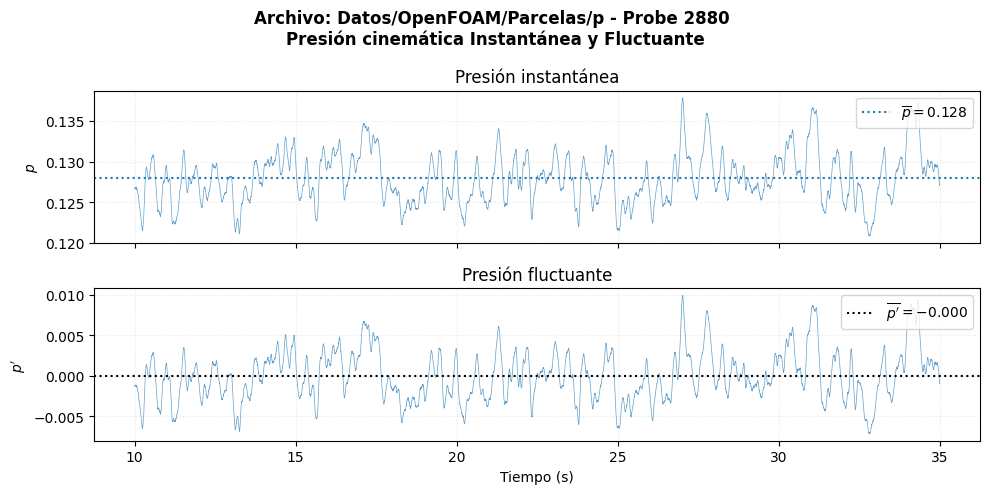

In [4]:
# Probe a visualizar
probe_1 = 2880
# Visualización de señal de presión
p1, t1, _ = imta.recortar_tiempo(p_probes, probe=probe_1, inicio=inicio)
p1_fluc, _ = imta.fluctuante(p1, tiempo=t1)

imta.plot_p(t1, p1_fluc,
            titulo=f'Archivo: {file_p} - Probe {probe_1} \nPresión cinemática Instantánea y Fluctuante',
            etiqueta='p');

In [5]:
# # Proceso de velocidad
# u1_a, u2_a, u3_a, tU_a, dfU_a = imta.recortar_tiempo(U_probes, probe=probe_1, inicio=inicio)
# u1_fluc, _ = imta.fluctuante(u1_a, tiempo=tU_a)
# u2_fluc, _ = imta.fluctuante(u2_a, tiempo=tU_a)
# u3_fluc, _ = imta.fluctuante(u3_a, tiempo=tU_a)

# imta.plot_ui(tU_a, u1_fluc, u2_fluc, u3_fluc,
#             titulo=f'Archivo: {file_U} - Probe {probe_1} \nVelocidades Instantáneas y Fluctuantes',
#             etiquetas=('u_1', 'u_2', 'u_3'));

### **4. Discretizacion angular de la superficie**

Cada cilindro cuenta con sondas de presion distribuidas uniformemente en su perimetro, separadas cada $\Delta\theta = 10°$, lo que resulta en 36 sondas por cilindro cubriendo el rango $\theta \in [0°, 350°]$.

El angulo $\theta$ se mide desde el punto de estancamiento frontal en sentido antihorario. A cada cilindro $k$ se le asigna un subconjunto consecutivo de indices de sondas:

$$\text{Cilindro } k: \quad \text{probes} = \left[ 36k, \; 36k+1, \; \ldots, \; 36(k+1)-1 \right]$$

In [6]:
# Creación de vector con ángulos
angulos_deg = np.arange(0, 360, 10)
angulos_rad = np.radians(angulos_deg) # Conversión a radianes
dtheta = angulos_rad[1]-angulos_rad[0] # Paso de ángulo

num_cil = 80 
allprobes = np.arange(0, num_cil, 1) 

# Iniciar el diccionario vacío
cilindros = {}

for probe_i in allprobes:
    puntos_i = list(range(probe_i * angulos_deg.size, (probe_i + 1) * angulos_deg.size))
    
    # Guardar lista en el diccionario usando probe_i como índice
    cilindros[probe_i] = puntos_i

# Prueba
# print("Puntos del cilindro 1:")
# print(cilindros[0])
# print("Puntos del cilindro -1:")
# print(cilindros[num_cil-1])

In [7]:
# Datos de: p_inf
print('p_inf (media) en cada plano')
print(f'y=0.20: {(np.mean(p_probes[2880])*rho):2f} Pa')
print(f'y=0.40: {(np.mean(p_probes[2881])*rho):2f} Pa')
print(f'y=0.65: {(np.mean(p_probes[2882])*rho):2f} Pa')
print(f'y=1.15: {(np.mean(p_probes[2883])*rho):2f} Pa')

p_inf (media) en cada plano
y=0.20: 131.198502 Pa
y=0.40: 144.513229 Pa
y=0.65: 156.699448 Pa
y=1.15: 171.609543 Pa


### **5. Coeficiente de presion $C_p(\theta)$**

#### 5.1 Definicion

El coeficiente de presion se define como la presion adimensionalizada respecto a la presion dinamica del flujo libre:

$$C_p(\theta) = \frac{\overline{p}(\theta) - p_\infty}{\dfrac{1}{2}\,\rho\, U_\infty^2}$$

donde:
- $\overline{p}(\theta)$ es la presion estatica promediada en el tiempo en la posicion angular $\theta$,
- $p_\infty$ es la presion de referencia del flujo libre (medida en una sonda testigo alejada de los cilindros),
- $\frac{1}{2}\rho U_\infty^2$ es la presion dinamica.

#### 5.2 Procedimiento de calculo

1. Se extrae la serie temporal de presion cinematica $p_k(t, \theta_j)$ en cada sonda $j$.
2. Se convierte a presion estatica en Pa: $p(t, \theta_j) = \rho \cdot p_k(t, \theta_j)$.
3. Se calcula el promedio temporal: $\overline{p}(\theta_j) = \dfrac{1}{T}\displaystyle\int_0^T p(t, \theta_j)\, dt$.
4. Se normaliza:

$$C_p(\theta_j) = \frac{\overline{p}(\theta_j) - p_\infty}{\dfrac{1}{2}\,\rho\, U_\infty^2}$$

#### 5.3 Solucion teorica: flujo potencial

Para un cilindro circular aislado en flujo potencial (irrotacional, no viscoso), la distribucion de presion sobre la superficie tiene solucion analitica:

$$C_p^{\text{pot}}(\theta) = 1 - 4\,\sin^2(\theta)$$

Esta expresion se utiliza como referencia para comparar con los resultados de la simulacion. Las diferencias respecto a la solucion de flujo potencial reflejan los efectos de la viscosidad, la separacion de la capa limite y la estela turbulenta.

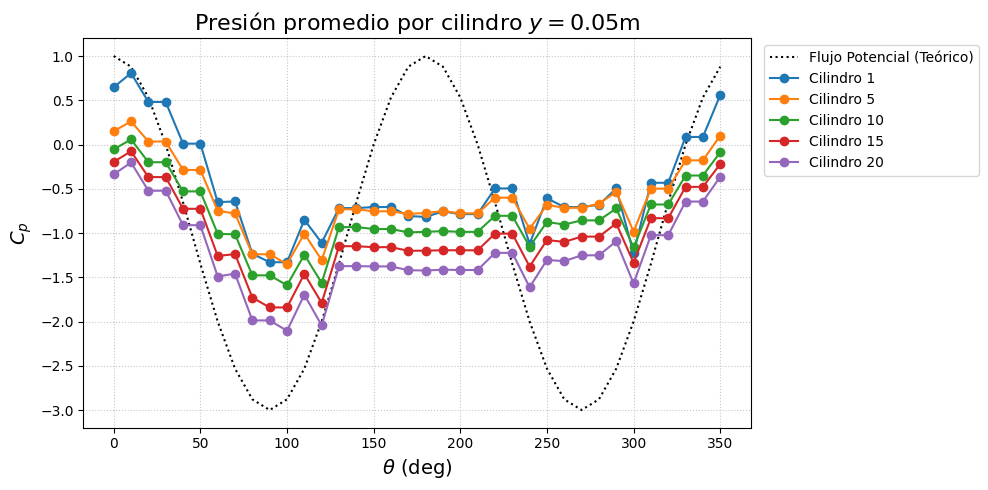

In [8]:
# Plano de 0.020 [Cilindro 1 al 20]
U_inf = 0.530  # m/s
p_inf = 131.198 # Pa

Cp_teorico = 1 - 4 * (np.sin(angulos_rad)**2)

# Declaración de diccionarios
Cp = {}
p_pa = {}

# Ciclo para calcular Cp y p_pa por cada cilindro
for i in cilindros.keys():
    # Uso de función cp_promedio_por_theta
    Cp[i], p_pa[i] = imta.cp_promedio_por_theta(p_probes, cilindros[i], rho, U_inf, p_inf, t_ini=inicio)

# Graficando serie para pada Cp
plt.figure(figsize=(10, 5))

plt.plot(angulos_deg, Cp_teorico, 'k:', linewidth=1.5, label='Flujo Potencial (Teórico)')

# # Para todas probes
# for i in Cp.keys():
#     plt.plot(angulos_deg, Cp[i], '.-', label=f'Cilindro {i+1}')

# Para probes especificas
cilindros_a_graficar = [0, 4, 9, 14, 19] # índices de cilindros a graficar 0=cilindro1, 2=cilindro2, 4=cilindro3
#cilindros_a_graficar = np.linspace(0, 19, 20) # Primeros 20 cilindros

for i in cilindros_a_graficar:
    plt.plot(angulos_deg, Cp[i], 'o-', label=f'Cilindro {i+1}')

plt.xlabel(r'$\theta$ (deg)', fontsize=14)
plt.ylabel(r'$C_p$', fontsize=14)
plt.title(r'Presión promedio por cilindro $y=0.05 \mathrm{m}$', fontsize=16)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()

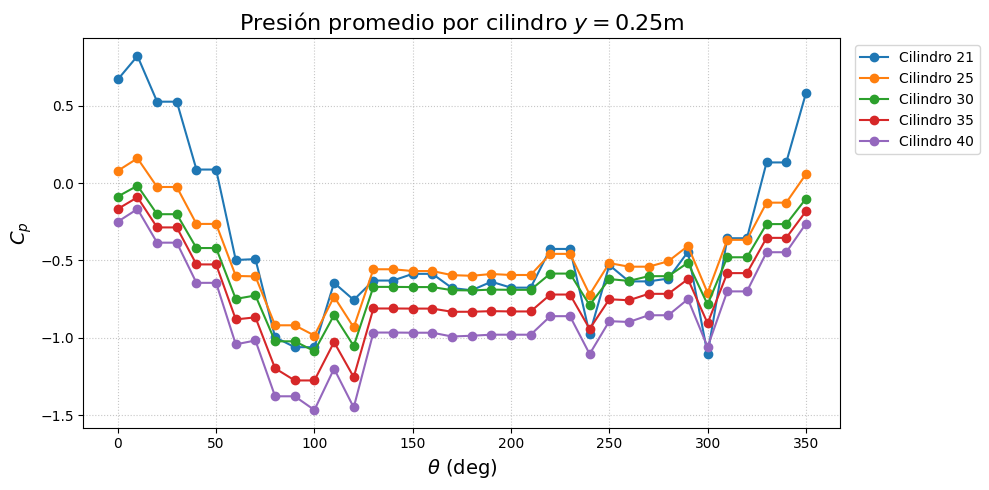

In [9]:
# Plano de 0.040 [Cilindro 21 al 40]
U_inf = 0.671  # m/s
p_inf = 144.51 # Pa

# Declaración de diccionarios
Cp = {}
p_pa = {}

# Ciclo para calcular Cp y p_pa por cada cilindro
for i in cilindros.keys():
    # Uso de función cp_promedio_por_theta
    Cp[i], p_pa[i] = imta.cp_promedio_por_theta(p_probes, cilindros[i], rho, U_inf, p_inf, t_ini=inicio)

# Graficando serie para pada Cp
plt.figure(figsize=(10, 5))

# # Para ver todas las probes
# for i in Cp.keys():
#     plt.plot(angulos_deg, Cp[i], '.-', label=f'Cilindro {i+1}')

# Para probes especificas
cilindros_a_graficar = [20, 24, 29, 34, 39] # índices de cilindros a graficar 0=cilindro1, 2=cilindro2, 4=cilindro3
#cilindros_a_graficar = np.linspace(0, 19, 20) # Primeros 20 cilindros

for i in cilindros_a_graficar:
    plt.plot(angulos_deg, Cp[i], 'o-', label=f'Cilindro {i+1}')

plt.xlabel(r'$\theta$ (deg)', fontsize=14)
plt.ylabel(r'$C_p$', fontsize=14)
plt.title(r'Presión promedio por cilindro $y=0.25 \mathrm{m}$', fontsize=16)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()

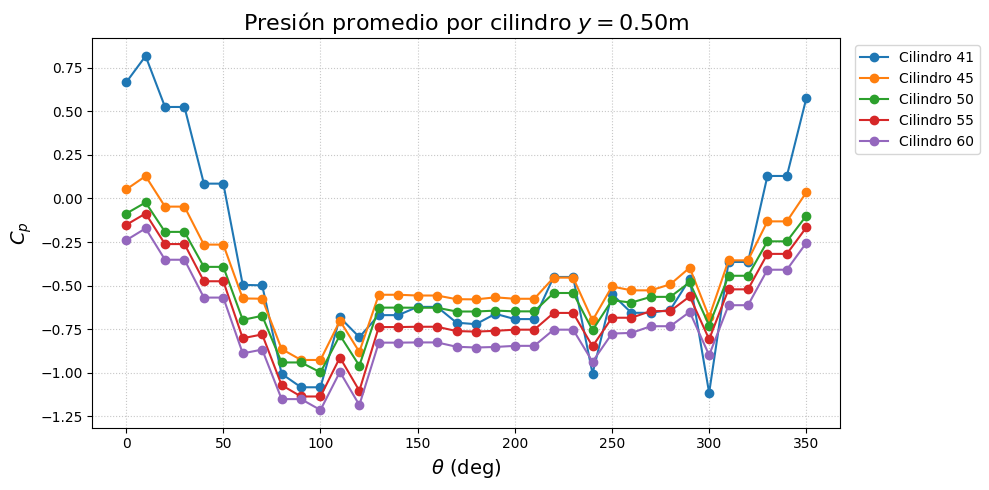

In [10]:
# Plano de 0.50 [Cilindro 41 al 60]
U_inf = 0.742  # m/s
p_inf = 156.694 # Pa

# Declaración de diccionarios
Cp = {}
p_pa = {}

# Ciclo para calcular Cp y p_pa por cada cilindro
for i in cilindros.keys():
    # Uso de función cp_promedio_por_theta
    Cp[i], p_pa[i] = imta.cp_promedio_por_theta(p_probes, cilindros[i], rho, U_inf, p_inf, t_ini=inicio)

# Graficando serie para pada Cp
plt.figure(figsize=(10, 5))

# # Para ver todas las probes
# for i in Cp.keys():
#     plt.plot(angulos_deg, Cp[i], '.-', label=f'Cilindro {i+1}')

# Para probes especificas
cilindros_a_graficar = [40, 44, 49, 54, 59] # índices de cilindros a graficar 0=cilindro1, 2=cilindro2, 4=cilindro3
#cilindros_a_graficar = np.linspace(0, 19, 20) # Primeros 20 cilindros

for i in cilindros_a_graficar:
    plt.plot(angulos_deg, Cp[i], 'o-', label=f'Cilindro {i+1}')

plt.xlabel(r'$\theta$ (deg)', fontsize=14)
plt.ylabel(r'$C_p$', fontsize=14)
plt.title(r'Presión promedio por cilindro $y=0.50 \mathrm{m}$', fontsize=16)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()

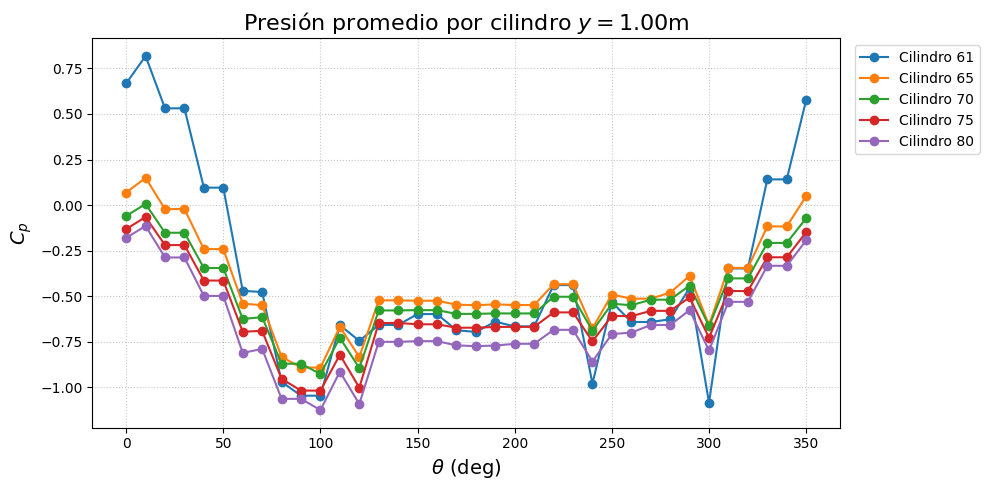

In [11]:
# Plano de 0.50 [Cilindro 61 al 80]
U_inf = 0.820  # m/s
p_inf = 171.609 # Pa

# Declaración de diccionarios
Cp = {}
p_pa = {}

# Ciclo para calcular Cp y p_pa por cada cilindro
for i in cilindros.keys():
    # Uso de función cp_promedio_por_theta
    Cp[i], p_pa[i] = imta.cp_promedio_por_theta(p_probes, cilindros[i], rho, U_inf, p_inf, t_ini=inicio)

# Graficando serie para pada Cp
plt.figure(figsize=(10, 5))

# # Para ver todas las probes
# for i in Cp.keys():
#     plt.plot(angulos_deg, Cp[i], '.-', label=f'Cilindro {i+1}')

# Para probes especificas
cilindros_a_graficar = [60, 64, 69, 74, 79] # índices de cilindros a graficar 0=cilindro1, 2=cilindro2, 4=cilindro3
#cilindros_a_graficar = np.linspace(0, 19, 20) # Primeros 20 cilindros

for i in cilindros_a_graficar:
    plt.plot(angulos_deg, Cp[i], 'o-', label=f'Cilindro {i+1}')

plt.xlabel(r'$\theta$ (deg)', fontsize=14)
plt.ylabel(r'$C_p$', fontsize=14)
plt.title(r'Presión promedio por cilindro $y=1.00 \mathrm{m}$', fontsize=16)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()

### **6. Coeficientes de arrastre $C_D$ y sustentacion $C_L$**

#### 6.1 Integracion de presion sobre la superficie

Las fuerzas hidrodinamicas sobre el cilindro se obtienen integrando la presion sobre su contorno. En coordenadas cilindricas, el vector normal unitario saliente en la posicion angular $\theta$ tiene componentes $\hat{n} = (\cos\theta, \sin\theta)$.

La fuerza por unidad de longitud axial resulta:

$$F_x = -\oint p(\theta)\,\cos\theta\; R\, d\theta \qquad \text{(arrastre)}$$

$$F_z = -\oint p(\theta)\,\sin\theta\; R\, d\theta \qquad \text{(sustentacion)}$$

En forma discreta, con $N$ sondas equiespaciadas a intervalos $\Delta\theta$:

$$F_x \approx -R\,\Delta\theta \sum_{j=1}^{N} p(\theta_j)\,\cos\theta_j$$

$$F_z \approx -R\,\Delta\theta \sum_{j=1}^{N} p(\theta_j)\,\sin\theta_j$$

#### 6.2 Fuerza total tridimensional

Para obtener la fuerza total sobre el cilindro, se multiplica por la envergadura $L$:

$$F_x^{\text{total}} = F_x \cdot L \qquad [\text{N}]$$

$$F_z^{\text{total}} = F_z \cdot L \qquad [\text{N}]$$

#### 6.3 Coeficientes adimensionales

Los coeficientes de arrastre y sustentacion se definen normalizando con la presion dinamica y el area frontal proyectada $A = D \cdot L$:

$$C_D(t) = \frac{F_x^{\text{total}}(t)}{\dfrac{1}{2}\,\rho\, U_\infty^2 \cdot A}$$

$$C_L(t) = \frac{F_z^{\text{total}}(t)}{\dfrac{1}{2}\,\rho\, U_\infty^2 \cdot A}$$

Ambos coeficientes son adimensionales y representan series temporales que caracterizan la evolucion de las fuerzas sobre cada cilindro a lo largo de la simulacion.

#### 6.5 Estadisticas temporales

A partir de las series temporales se obtienen los valores medios:

$$\overline{C_D} = \frac{1}{T}\int_0^T C_D(t)\,dt$$

$$\overline{C_L} = \frac{1}{T}\int_0^T C_L(t)\,dt$$

y las componentes fluctuantes:

$$C_D'(t) = C_D(t) - \overline{C_D}$$

$$C_L'(t) = C_L(t) - \overline{C_L}$$

El valor rms de las fluctuaciones proporciona una medida de la intensidad de la oscilacion de las fuerzas:

$$C_{D,\text{rms}} = \sqrt{\overline{C_D'^{\,2}}}$$

$$C_{L,\text{rms}} = \sqrt{\overline{C_L'^{\,2}}}$$

#### 6.6 Interpretacion fisica

| Coeficiente | Direccion | Significado |
|---|---|---|
| $C_D$ | Paralela al flujo ($x$) | Resistencia que el fluido ejerce sobre el cilindro |
| $C_L$ | Perpendicular al flujo ($z$) | Fuerza transversal asociada al desprendimiento de vortices |

<img src="./Datos/Imagenes/Fd_Fl.png" height="200" align="middle"> <br>
Mutlu, 2006. (Drag and lift force traces obtained from the measured pressure distributions)

Velocidad exterior = 0.53 m/s
Altura = 0.1 m

Cilindro         Fd_mean (N)    Fl_mean (N)    CD_mean    CL_mean
----------------------------------------------------------------
Cilindro 1          -0.348962       0.032710   -0.82820    0.07763
Cilindro 5          -0.238494       0.074246   -0.56602    0.17621
Cilindro 10         -0.240358       0.093644   -0.57045    0.22225
Cilindro 15         -0.260801       0.113439   -0.61896    0.26923
Cilindro 20         -0.282261       0.115495   -0.66990    0.27411


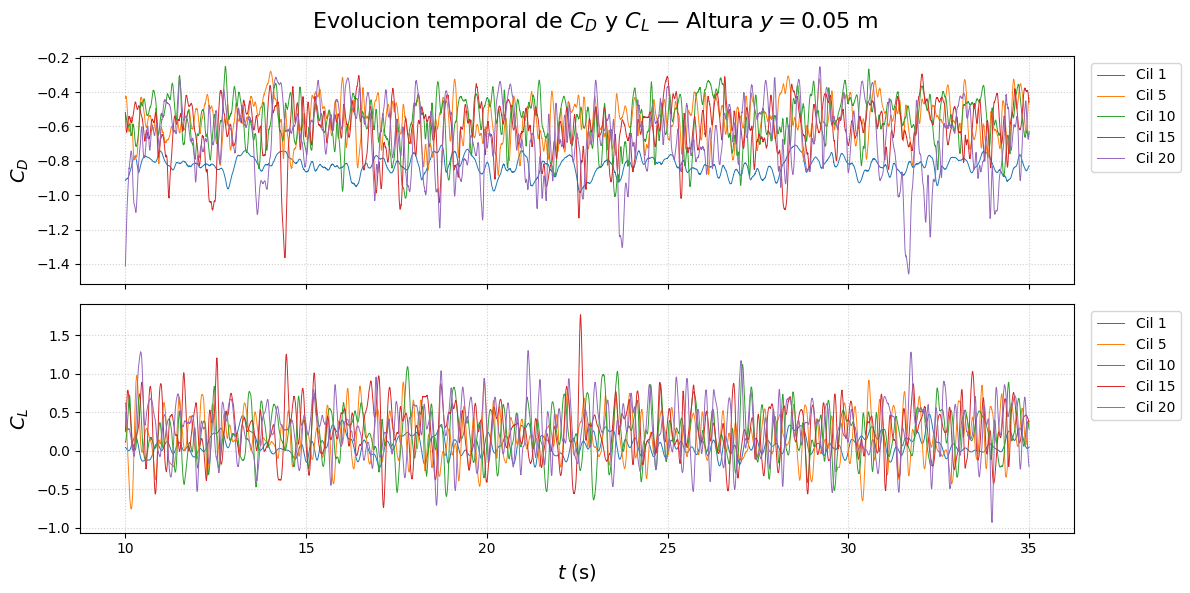

In [12]:
# Parametros 
U_inf = 0.530   # m/s
span = 0.10     # m (Envergadura o altura de la pila)
D = 0.03        # m (Diámetro de los cilindros)
R = D / 2       # m (Radio de los cilindros)

# Extraer presion y calcular CD, CL por cada cilindro
CD = {}
CL = {}
Fx = {}
Fz = {}
p_theta_dict = {}

for i in cilindros.keys():
    p_theta_i, t_i = imta.extraer_p_theta(p_probes, cilindros[i], t_inicio=inicio)
    p_theta_dict[i] = p_theta_i
    CD[i], CL[i], Fx[i], Fz[i] = imta.cd_cl_integrando_p(p_theta_i, angulos_rad, rho, U_inf, R, D, span)

# === Graficas de CD y CL para cilindros seleccionados ===
cilindros_a_graficar = [0, 4, 9, 14, 19]
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

print(f"Velocidad exterior = {U_inf} m/s")
print(f"Altura = {span} m")
print(f"{'\nCilindro':<14} {'Fd_mean (N)':>14} {'Fl_mean (N)':>14} {'CD_mean':>10} {'CL_mean':>10}")
print("-" * 64)

for i in cilindros_a_graficar:
    ax[0].plot(t_i, CD[i], linewidth=0.7, label=f'Cil {i+1}')
    ax[1].plot(t_i, CL[i], linewidth=0.7, label=f'Cil {i+1}')
    print(f"{'Cilindro ' + str(i+1):<14} "
    f"{np.mean(Fx[i]):>14.6f} "
    f"{np.mean(Fz[i]):>14.6f} "
    f"{np.mean(CD[i]):>10.5f} "
    f"{np.mean(CL[i]):>10.5f}")

# Panel superior: CD
ax[0].set_ylabel(r'$C_D$', fontsize=14)
ax[0].grid(True, linestyle=':', alpha=0.6)
ax[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left')

# Panel inferior: CL
ax[1].set_ylabel(r'$C_L$', fontsize=14)
ax[1].set_xlabel(r'$t$ (s)', fontsize=14)
ax[1].grid(True, linestyle=':', alpha=0.6)
ax[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left')

plt.suptitle(r'Evolucion temporal de $C_D$ y $C_L$ — Altura $y=0.05$ m', fontsize=16)
plt.tight_layout()

Velocidad exterior = 0.671 m/s
Altura = 0.25 m

Cilindro         Fd_mean (N)    Fl_mean (N)    CD_mean    CL_mean
----------------------------------------------------------------
Cilindro 21         -1.291746      -0.018609   -0.76507   -0.01102
Cilindro 25         -0.690976       0.231683   -0.40925    0.13722
Cilindro 30         -0.621100       0.272613   -0.36786    0.16146
Cilindro 35         -0.699958       0.330452   -0.41457    0.19572
Cilindro 40         -0.781069       0.355830   -0.46261    0.21075


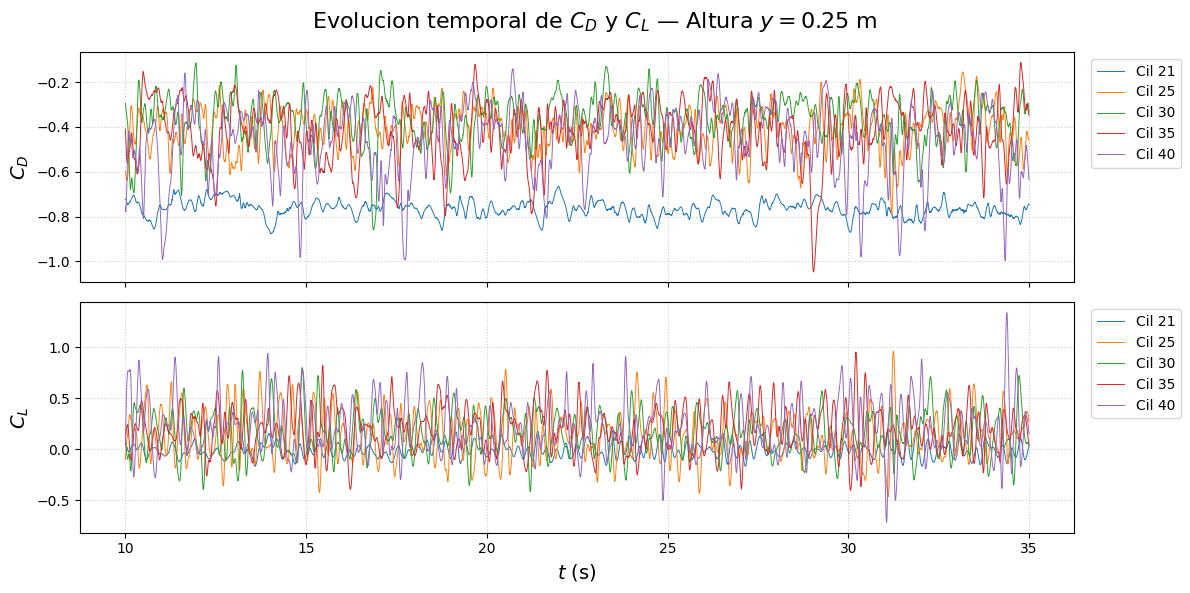

In [13]:
# Parametros 
U_inf = 0.671   # m/s
span = 0.25     # m (Envergadura o altura de la pila)
D = 0.03        # m (Diámetro de los cilindros)
R = D / 2       # m (Radio de los cilindros)

# Extraer presion y calcular CD, CL por cada cilindro
CD = {}
CL = {}
Fx = {}
Fz = {}
p_theta_dict = {}

for i in cilindros.keys():
    p_theta_i, t_i = imta.extraer_p_theta(p_probes, cilindros[i], t_inicio=inicio)
    p_theta_dict[i] = p_theta_i
    CD[i], CL[i], Fx[i], Fz[i] = imta.cd_cl_integrando_p(p_theta_i, angulos_rad, rho, U_inf, R, D, span)

# === Graficas de CD y CL para cilindros seleccionados ===
cilindros_a_graficar = [20, 24, 29, 34, 39]
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

print(f"Velocidad exterior = {U_inf} m/s")
print(f"Altura = {span} m")
print(f"{'\nCilindro':<14} {'Fd_mean (N)':>14} {'Fl_mean (N)':>14} {'CD_mean':>10} {'CL_mean':>10}")
print("-" * 64)

for i in cilindros_a_graficar:
    ax[0].plot(t_i, CD[i], linewidth=0.7, label=f'Cil {i+1}')
    ax[1].plot(t_i, CL[i], linewidth=0.7, label=f'Cil {i+1}')
    print(f"{'Cilindro ' + str(i+1):<14} "
    f"{np.mean(Fx[i]):>14.6f} "
    f"{np.mean(Fz[i]):>14.6f} "
    f"{np.mean(CD[i]):>10.5f} "
    f"{np.mean(CL[i]):>10.5f}")

# Panel superior: CD
ax[0].set_ylabel(r'$C_D$', fontsize=14)
ax[0].grid(True, linestyle=':', alpha=0.6)
ax[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left')

# Panel inferior: CL
ax[1].set_ylabel(r'$C_L$', fontsize=14)
ax[1].set_xlabel(r'$t$ (s)', fontsize=14)
ax[1].grid(True, linestyle=':', alpha=0.6)
ax[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left')

plt.suptitle(r'Evolucion temporal de $C_D$ y $C_L$ — Altura $y=0.25$ m', fontsize=16)
plt.tight_layout()

Velocidad exterior = 0.742 m/s
Altura = 0.5 m

Cilindro         Fd_mean (N)    Fl_mean (N)    CD_mean    CL_mean
----------------------------------------------------------------
Cilindro 41         -3.261359      -0.035500   -0.78982   -0.00860
Cilindro 45         -1.602071       0.534922   -0.38798    0.12955
Cilindro 50         -1.414839       0.587204   -0.34264    0.14221
Cilindro 55         -1.563379       0.706766   -0.37861    0.17116
Cilindro 60         -1.567393       0.665064   -0.37958    0.16106


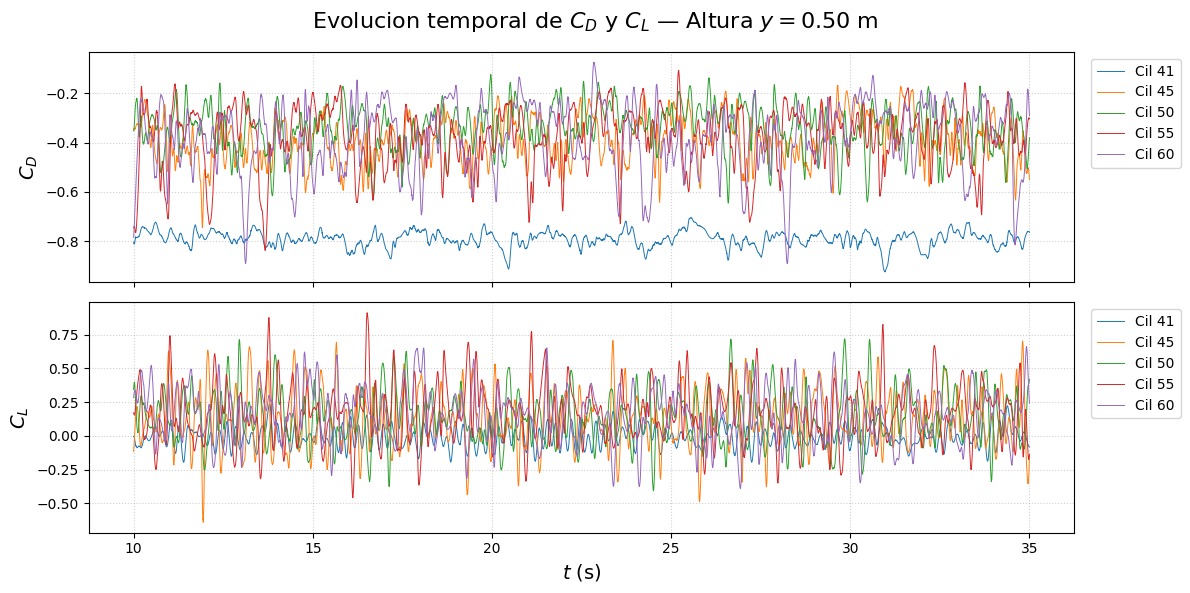

In [14]:
# Parametros 
U_inf = 0.742   # m/s
span = 0.50     # m (Envergadura o altura de la pila)
D = 0.03        # m (Diámetro de los cilindros)
R = D / 2       # m (Radio de los cilindros)

# Extraer presion y calcular CD, CL por cada cilindro
CD = {}
CL = {}
Fx = {}
Fz = {}
p_theta_dict = {}

for i in cilindros.keys():
    p_theta_i, t_i = imta.extraer_p_theta(p_probes, cilindros[i], t_inicio=inicio)
    p_theta_dict[i] = p_theta_i
    CD[i], CL[i], Fx[i], Fz[i] = imta.cd_cl_integrando_p(p_theta_i, angulos_rad, rho, U_inf, R, D, span)

# === Graficas de CD y CL para cilindros seleccionados ===
cilindros_a_graficar = [40, 44, 49, 54, 59]
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

print(f"Velocidad exterior = {U_inf} m/s")
print(f"Altura = {span} m")
print(f"{'\nCilindro':<14} {'Fd_mean (N)':>14} {'Fl_mean (N)':>14} {'CD_mean':>10} {'CL_mean':>10}")
print("-" * 64)

for i in cilindros_a_graficar:
    ax[0].plot(t_i, CD[i], linewidth=0.7, label=f'Cil {i+1}')
    ax[1].plot(t_i, CL[i], linewidth=0.7, label=f'Cil {i+1}')
    print(f"{'Cilindro ' + str(i+1):<14} "
    f"{np.mean(Fx[i]):>14.6f} "
    f"{np.mean(Fz[i]):>14.6f} "
    f"{np.mean(CD[i]):>10.5f} "
    f"{np.mean(CL[i]):>10.5f}")

# Panel superior: CD
ax[0].set_ylabel(r'$C_D$', fontsize=14)
ax[0].grid(True, linestyle=':', alpha=0.6)
ax[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left')

# Panel inferior: CL
ax[1].set_ylabel(r'$C_L$', fontsize=14)
ax[1].set_xlabel(r'$t$ (s)', fontsize=14)
ax[1].grid(True, linestyle=':', alpha=0.6)
ax[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left')

plt.suptitle(r'Evolucion temporal de $C_D$ y $C_L$ — Altura $y=0.50$ m', fontsize=16)
plt.tight_layout()

Velocidad exterior = 0.82 m/s
Altura = 1.0 m

Cilindro         Fd_mean (N)    Fl_mean (N)    CD_mean    CL_mean
----------------------------------------------------------------
Cilindro 61         -7.848574      -0.166439   -0.77817   -0.01650
Cilindro 65         -3.823616       1.153858   -0.37910    0.11440
Cilindro 70         -3.358952       1.320132   -0.33303    0.13089
Cilindro 75         -3.412757       1.487659   -0.33837    0.14750
Cilindro 80         -3.747241       1.594859   -0.37153    0.15813


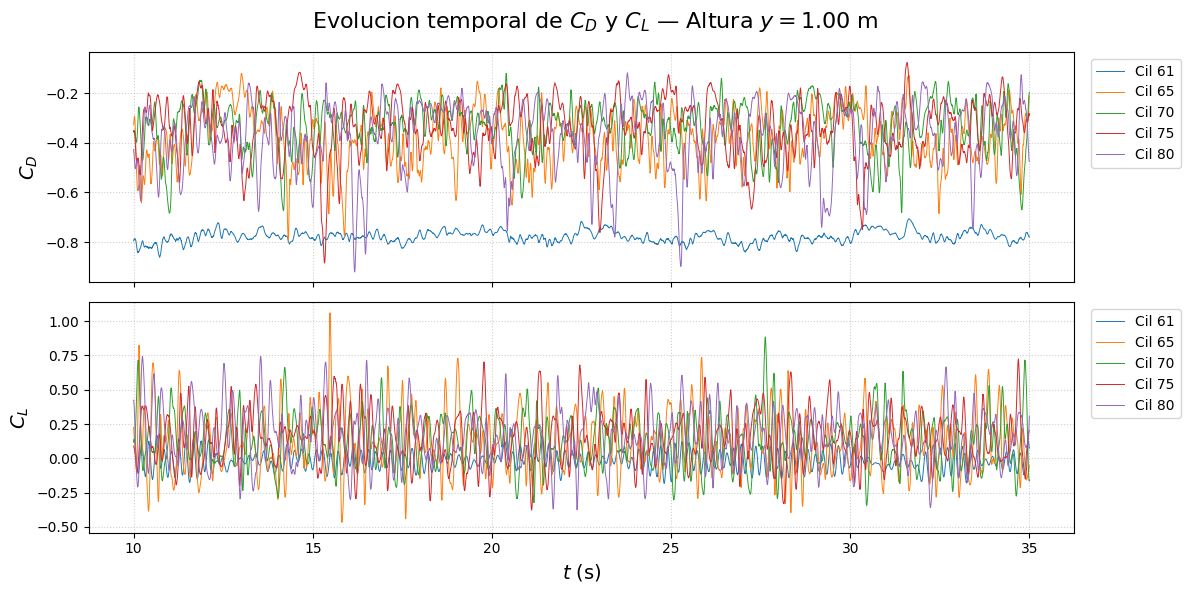

In [15]:
# Parametros 
U_inf = 0.820   # m/s
span = 1.00     # m (Envergadura o altura de la pila)
D = 0.03        # m (Diámetro de los cilindros)
R = D / 2       # m (Radio de los cilindros)

# Extraer presion y calcular CD, CL por cada cilindro
CD = {}
CL = {}
Fx = {}
Fz = {}
p_theta_dict = {}

for i in cilindros.keys():
    p_theta_i, t_i = imta.extraer_p_theta(p_probes, cilindros[i], t_inicio=inicio)
    p_theta_dict[i] = p_theta_i
    CD[i], CL[i], Fx[i], Fz[i] = imta.cd_cl_integrando_p(p_theta_i, angulos_rad, rho, U_inf, R, D, span)

# === Graficas de CD y CL para cilindros seleccionados ===
cilindros_a_graficar = [60, 64, 69, 74, 79]
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

print(f"Velocidad exterior = {U_inf} m/s")
print(f"Altura = {span} m")
print(f"{'\nCilindro':<14} {'Fd_mean (N)':>14} {'Fl_mean (N)':>14} {'CD_mean':>10} {'CL_mean':>10}")
print("-" * 64)

for i in cilindros_a_graficar:
    ax[0].plot(t_i, CD[i], linewidth=0.7, label=f'Cil {i+1}')
    ax[1].plot(t_i, CL[i], linewidth=0.7, label=f'Cil {i+1}')
    print(f"{'Cilindro ' + str(i+1):<14} "
    f"{np.mean(Fx[i]):>14.6f} "
    f"{np.mean(Fz[i]):>14.6f} "
    f"{np.mean(CD[i]):>10.5f} "
    f"{np.mean(CL[i]):>10.5f}")

# Panel superior: CD
ax[0].set_ylabel(r'$C_D$', fontsize=14)
ax[0].grid(True, linestyle=':', alpha=0.6)
ax[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left')

# Panel inferior: CL
ax[1].set_ylabel(r'$C_L$', fontsize=14)
ax[1].set_xlabel(r'$t$ (s)', fontsize=14)
ax[1].grid(True, linestyle=':', alpha=0.6)
ax[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left')

plt.suptitle(r'Evolucion temporal de $C_D$ y $C_L$ — Altura $y=1.00$ m', fontsize=16)
plt.tight_layout()